# Volleyball Tagging System: Data Exploration

Authors: Patrick Dang, Abiola Raji

## Setup

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as T
import torch
from torch.utils.data import DataLoader, random_split

import torchmetrics

In [2]:
path = Path("./VolleyballDataset")

if not path.exists():
   print("Dataset not found")
else:
    print("Volleyball Dataset Found")

Dataset not found


## Preprocessing & Data Loading

In [3]:
from model.transformations import train_transform, val_transform

BATCH = 32

torch.manual_seed(12345)

train_set = ImageFolder(path / "train", train_transform)
val_set = ImageFolder(path / "valid", val_transform)

# Data Loaders
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH)

### Class Distribution

In [4]:
class_names = train_set.classes
print(len(class_names),"classes")
class_names

5 classes


['block', 'defense', 'serve', 'set', 'spike']

In [5]:
from collections import Counter

all_labels = [label for _, label in train_set.samples]
counts = Counter(all_labels)

for idx, count in sorted(counts.items()):
    print(f"{class_names[idx]:<30} {count}")

print(f"\nTotal samples: {len(all_labels)}")
print(f"Total classes: {len(class_names)}")

block                          3564
defense                        103
serve                          1564
set                            3417
spike                          4152

Total samples: 12800
Total classes: 5


/var/folders/db/8x5sc8bx3g14nljyt4k3t4kw0000gn/T/ipykernel_6128/2798266946.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


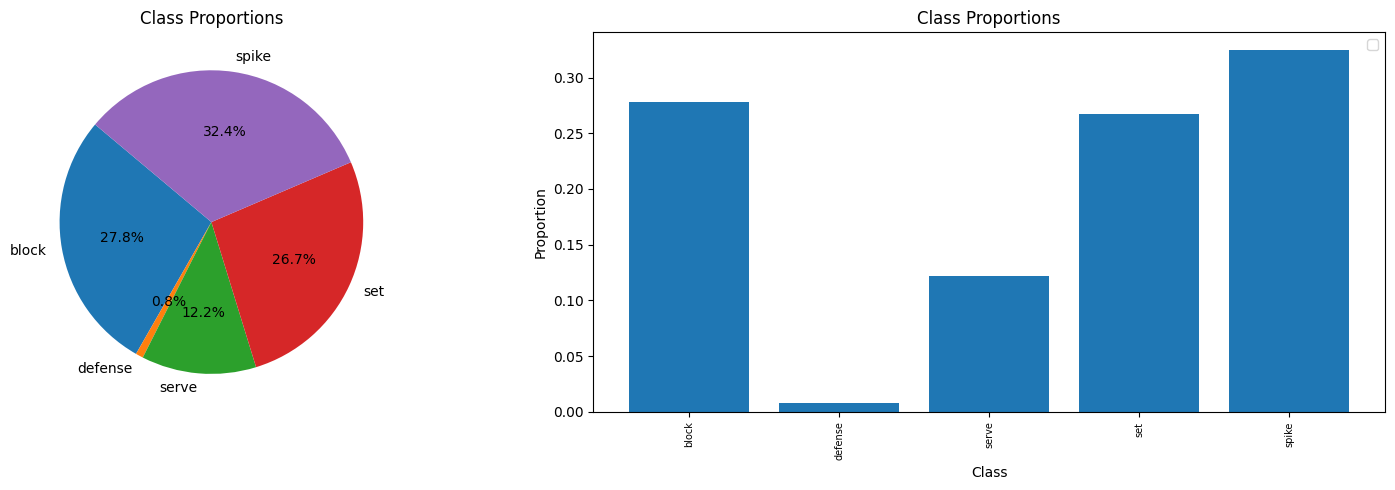

In [6]:
all_labels_train = [label for _, label in train_set.samples]
counts_train = Counter(all_labels_train)
proportions = [counts_train[i] / len(all_labels_train) for i in range(len(class_names))]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pie chart
axes[0].pie(proportions, labels=class_names, autopct="%1.1f%%", startangle=140)
axes[0].set_title("Class Proportions")

# Normalized bar
axes[1].bar(class_names, proportions)
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Proportion")
axes[1].set_title("Class Proportions")
axes[1].legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

### Train/Validation Split

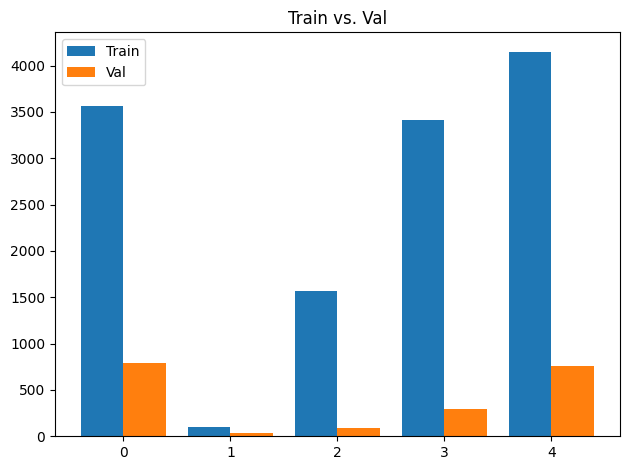

In [7]:
train_counts = Counter(label for _, label in train_set.samples)
val_counts   = Counter(label for _, label in val_set.samples)

x = np.arange(len(class_names))
width = 0.4

plt.bar(x - width/2, [train_counts[i] for i in range(len(class_names))], width, label="Train")
plt.bar(x + width/2, [val_counts[i]   for i in range(len(class_names))], width, label="Val")
plt.title("Train vs. Val")
plt.legend()

plt.tight_layout()
plt.show()

### Random Samples

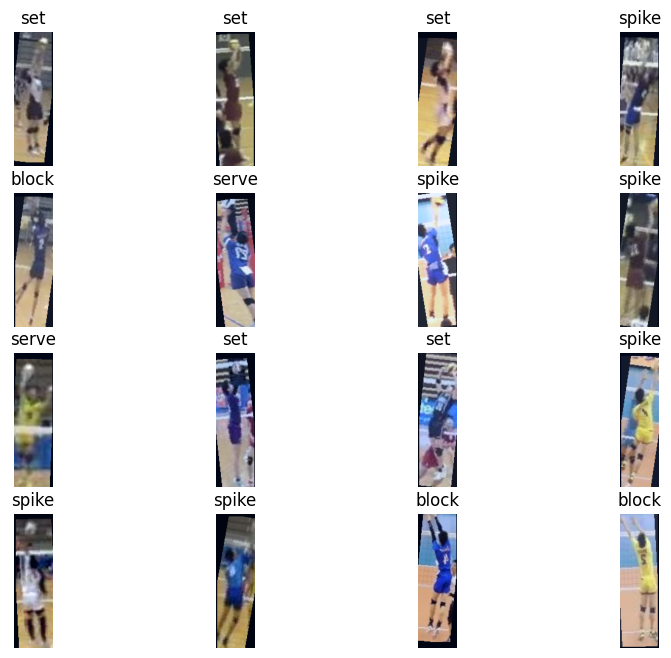

torch.Size([32, 3, 224, 64])


In [8]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 4, figsize=(10,8))
for i, ax in enumerate(axes.flatten()):
    im = images[i].permute(1, 2, 0).cpu().numpy()
    im -= im.min()
    im /= im.max()
    ax.imshow(im)
    ax.set_title(class_names[labels[i]])
    ax.axis("off")
plt.show()

print(images.shape)